In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def generate_float_values(exponent_bits, mantissa_bits, bias,has_nan_inf=False):
    """
    Generate all positive float values for a custom float format.
    
    Args:
        exponent_bits (int): Number of bits for exponent (X)
        mantissa_bits (int): Number of bits for mantissa (Y)
        bias (int): Exponent bias (B)
    
    Returns:
        numpy array of all positive float values
    """
    values = []
    max_exp = (1 << exponent_bits) - 1  # 2^X - 1
    max_mantissa = (1 << mantissa_bits) - 1  # 2^Y - 1
    
    for exp in range(max_exp + 1):
        # Skip infinity/NaN (all exponent bits set)
        if has_nan_inf and exp == max_exp:
            continue
            
        for mantissa in range(max_mantissa + 1):
            if exp == 0:
                # Denormalized numbers (exponent = 0)
                if mantissa == 0:
                    value = 0.0
                else:
                    # No implicit leading 1
                    value = 2.0 ** (1 - bias) * (mantissa / (1 << mantissa_bits))
            else:
                # Normalized numbers
                # Implicit leading 1 + fractional mantissa
                value = 2.0 ** (exp - bias) * (1.0 + mantissa / (1 << mantissa_bits))
            
            values.append(value)
    
    return np.array(sorted(set(values)))

In [17]:


def plot_float_levels(X, Y, B, axis=None):
    """
    Plot positive float levels normalized by max value and their inverses for UE{X}M{Y} format with bias B.
    
    Args:
        X (int): Exponent bits
        Y (int): Mantissa bits
        B (int): Bias
    """
    # Generate all positive levels
    levels_raw = generate_float_values(X, Y, B)
    max_val = levels_raw.max() if len(levels_raw) > 0 else 1.0
    levels = levels_raw / max_val
    
    # Remove zero for inverse calculation
    levels_nonzero = levels[levels > 0]
    inverses = 1.0 / levels_nonzero
    
    ax1 = axis
    if not axis:
        fig, ax1 = plt.subplots(1,1, figsize=(16, 8))
    
    
    # Plot 1: Positive levels (staircase)
    # ax1 = ax
    ax1.step(range(len(levels)), levels, where='post', linewidth=1.5, alpha=0.8)
    # ax1.scatter(range(len(levels)), levels, s=20, alpha=0.6, zorder=5)
    ax1.set_xlabel('Level Index', fontsize=12)
    ax1.set_ylabel('Float Value / Max', fontsize=12)
    ax1.set_title(f'Normalized Positive Levels - UE{X}M{Y} (Bias={B})\nMax Value: {max_val:.4e}', fontsize=14)
    # ax1.set_yscale('log')
    # ax1.set_xscale('log')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Inverses (staircase)
    # ax2 = axes[1]
    # ax2.step(range(len(inverses)), inverses, where='post', linewidth=1.5, alpha=0.8, color='orange')
    # ax2.scatter(range(len(inverses)), inverses, s=20, alpha=0.6, color='darkorange', zorder=5)
    # ax2.set_xlabel('Level Index', fontsize=12)
    # ax2.set_ylabel('Inverse Value (Max / x)', fontsize=12)
    # ax2.set_title(f'Inverse Normalized Levels - UE{X}M{Y} (Bias={B})', fontsize=14)
    # ax2.set_yscale('log')

    # ax2.grid(True, alpha=0.3)
    
    # plt.show()
    
    # Print statistics
    print(f"\n{'='*60}")
    print(f"Float Format: UE{X}M{Y} with Bias {B}")
    print(f"{'='*60}")
    print(f"Exponent bits: {X} (range: 0 to {(1 << X) - 1})")
    print(f"Mantissa bits: {Y}")
    print(f"Total representable positive values: {len(levels)}")
    print(f"\nValue Range:")
    print(f"  Minimum (non-zero): {levels[levels > 0].min():.6e}")
    print(f"  Maximum: {levels.max():.6e}")
    print(f"  Dynamic range: {levels.max() / levels[levels > 0].min():.6e}")
    # print(f"\nInverse Range:")
    # print(f"  Minimum: {inverses.min():.6e}")
    # print(f"  Maximum: {inverses.max():.6e}")
    # print(f"{'='*60}\n")
    
    return levels_raw, inverses, ax1

# Example: Plot for common configurations
# Uncomment the ones you want to try:

# IEEE 754 half precision (float16): E5M10, bias=15
# plot_float_levels(5, 10, 15)

# IEEE 754 single precision (float32): E8M23, bias=127
# plot_float_levels(8, 23, 127)

# Custom small format: E4M3, bias=7
# plot_float_levels(4, 3, 7)

# Custom tiny format: E3M2, bias=3
# plot_float_levels(3, 2, 3)


Float Format: UE2M3 with Bias 1
Exponent bits: 2 (range: 0 to 3)
Mantissa bits: 3
Total representable positive values: 32

Value Range:
  Minimum (non-zero): 1.666667e-02
  Maximum: 1.000000e+00
  Dynamic range: 6.000000e+01

Float Format: UE2M1 with Bias 1
Exponent bits: 2 (range: 0 to 3)
Mantissa bits: 1
Total representable positive values: 8

Value Range:
  Minimum (non-zero): 8.333333e-02
  Maximum: 1.000000e+00
  Dynamic range: 1.200000e+01

Float Format: UE3M2 with Bias 3
Exponent bits: 3 (range: 0 to 7)
Mantissa bits: 2
Total representable positive values: 32

Value Range:
  Minimum (non-zero): 2.232143e-03
  Maximum: 1.000000e+00
  Dynamic range: 4.480000e+02


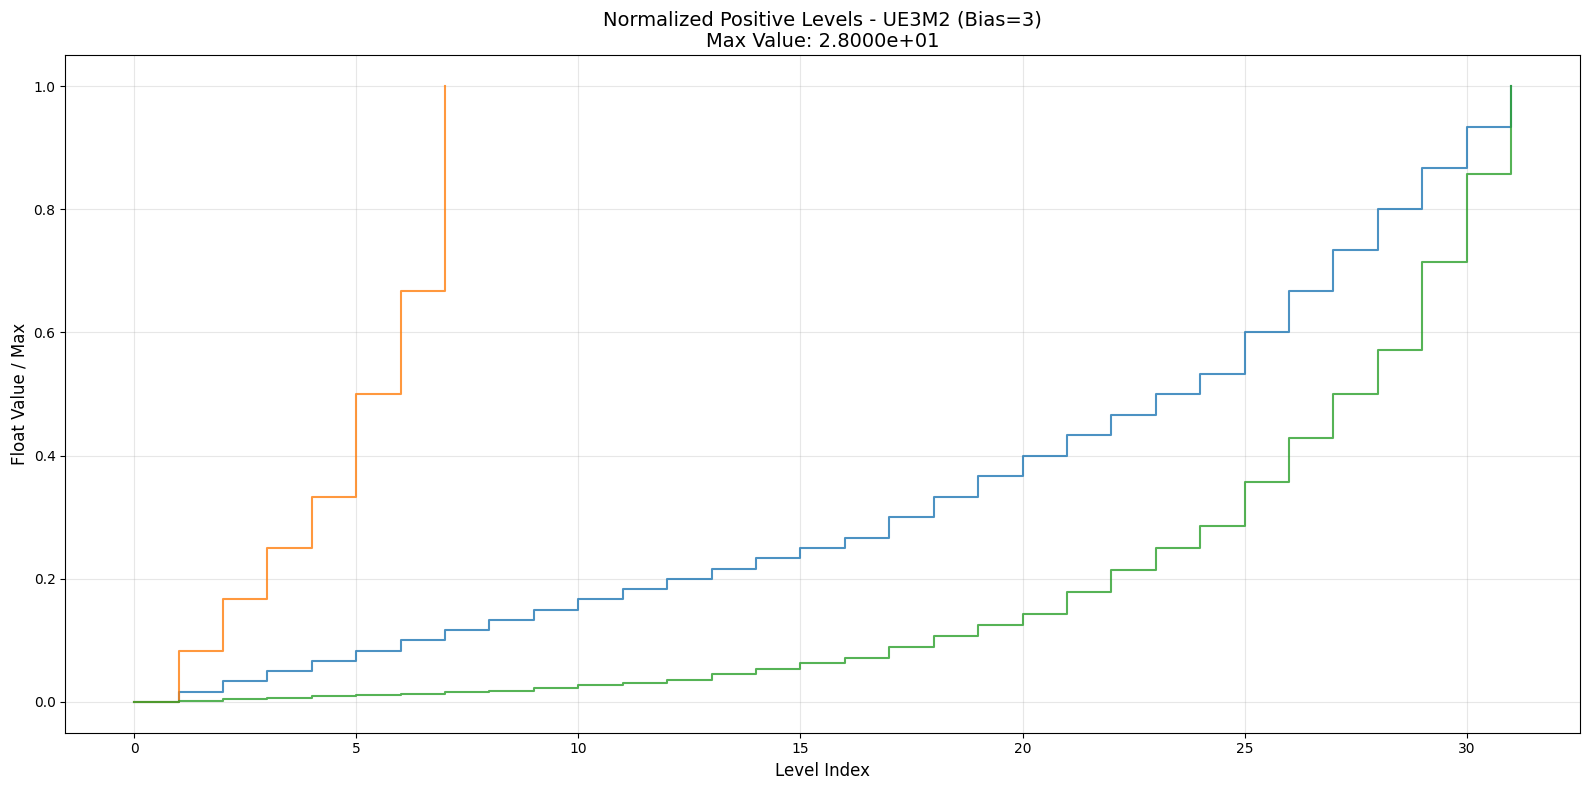

[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.    1.125 1.25  1.375
 1.5   1.625 1.75  1.875 2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
 4.    4.5   5.    5.5   6.    6.5   7.    7.5  ]
[ 0.      0.0625  0.125   0.1875  0.25    0.3125  0.375   0.4375  0.5
  0.625   0.75    0.875   1.      1.25    1.5     1.75    2.      2.5
  3.      3.5     4.      5.      6.      7.      8.     10.     12.
 14.     16.     20.     24.     28.    ]


In [20]:
levels,_, axe = plot_float_levels(2, 3, 1)
levels2,_,_ = plot_float_levels(2,1,1, axe)
levels2,_,_ = plot_float_levels(3,2,3, axe)

plt.tight_layout()
plt.show()
print(levels)
print(levels2)


Float Format: UE8M0 with Bias 127
Exponent bits: 8 (range: 0 to 255)
Mantissa bits: 0
Total representable positive values: 255

Value Range:
  Minimum (non-zero): 6.908935e-77
  Maximum: 1.000000e+00
  Dynamic range: 1.447401e+76


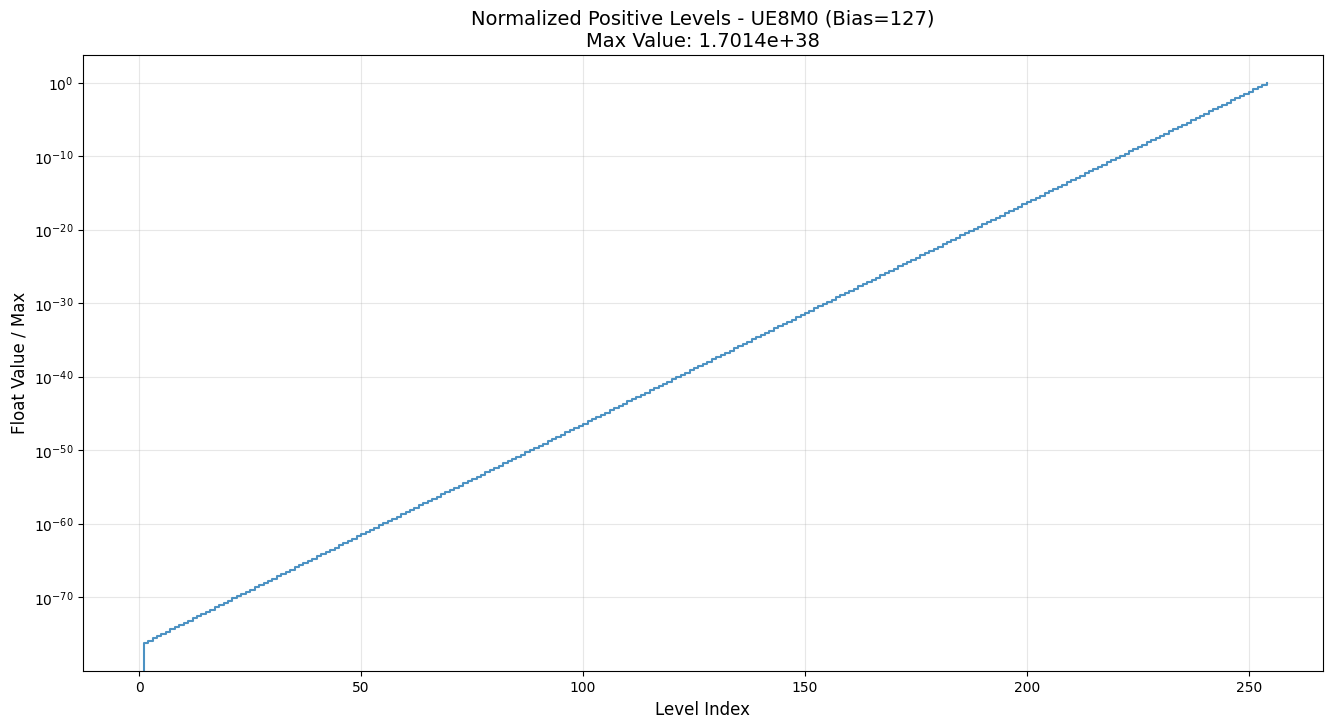

In [60]:
x = plot_float_levels(8, 0, 127)

In [47]:
x = plot_float_levels(5, 3, 14, axe)
plt.show()

<Figure size 640x480 with 0 Axes>


Float Format: UE5M3 with Bias 14
Exponent bits: 5 (range: 0 to 31)
Mantissa bits: 3
Total representable positive values: 248

Value Range:
  Minimum (non-zero): 1.241763e-10
  Maximum: 1.000000e+00
  Dynamic range: 8.053064e+09

Inverse Range:
  Minimum: 1.000000e+00
  Maximum: 8.053064e+09

